 ** Project Title**

# [E-Commerce Product Performance & Customer Sentiment Analysis](https://)

**Problem Statement  
A leading e-commerce company like Amazon wants to maximize revenue, optimize pricing, and
improve customer satisfaction**

** SECTION 1:
Data Cleaning & Feature Engineering**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving amazon.csv to amazon.csv


In [ ]:
import pandas as pd

df=pd.read_csv("amazon.csv")
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             ₹39

In [ ]:
 # 1. Data Type Conversion
 # Convert discounted_price, actual_price, discount_percentage to numeric
df['discounted_price'] = pd.to_numeric(
    df['discounted_price'].astype(str).str.replace('₹','').str.replace(',',''),
    errors='coerce'
)

df['actual_price'] = pd.to_numeric(
    df['actual_price'].astype(str).str.replace('₹','').str.replace(',',''),
    errors='coerce'
)
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category  discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             39

In [ ]:
# Convert rating and rating_count to proper numeric types
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category  discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             39

In [ ]:
# 2. Missing Value Treatment
df.isnull().sum()

df['rating'].fillna(df['rating'].median(), inplace=True)
df['rating_count'].fillna(0, inplace=True)
df['review_content'].fillna("No Review", inplace=True)
df['category'].fillna("Unknown", inplace=True)

/tmp/ipykernel_2430/717162267.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)
/tmp/ipykernel_2430/717162267.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
#  3. Duplicate Handling
df.drop_duplicates(subset='product_id', inplace=True)
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category  discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             39

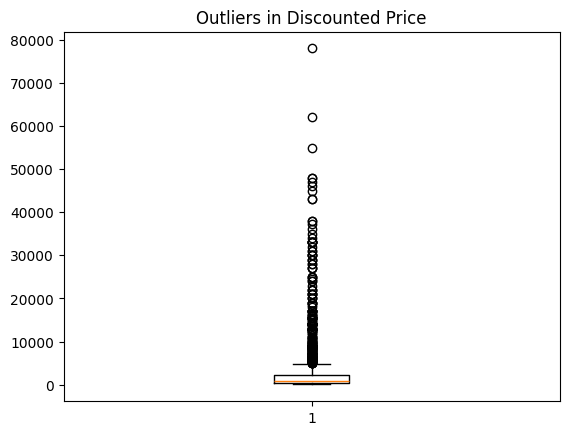

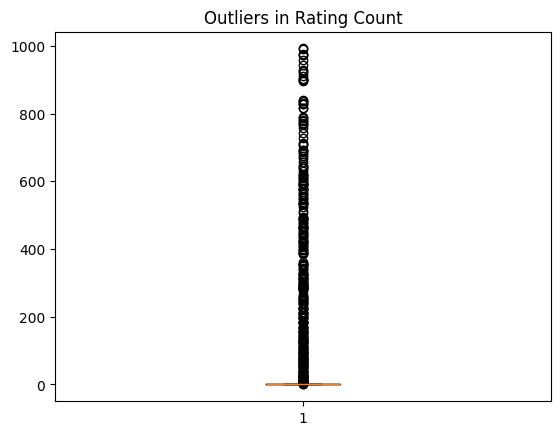

In [ ]:
# 4. Outlier Detection & Treatment (IMPORTANT)
#boxplot rating_count
import matplotlib.pyplot as plt

plt.boxplot(df['discounted_price'])
plt.title("Outliers in Discounted Price")
plt.show()

plt.boxplot(df['rating_count'])
plt.title("Outliers in Rating Count")
plt.show()

In [ ]:
# iqr method on dicounted price
Q1 = df['discounted_price'].quantile(0.25)
Q3 = df['discounted_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_price = df[(df['discounted_price'] < lower) | (df['discounted_price'] > upper)]

print("Outliers count:", len(outliers_price))

Outliers count: 209


In [ ]:
# treatmenmt method
#remove outliers
df = df[(df['discounted_price'] >= lower) & (df['discounted_price'] <= upper)]
df = df[(df['rating_count'] >= lower) & (df['rating_count'] <= upper)]
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category  discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             39

** SECTION 2: Visualization-Heavy EDA

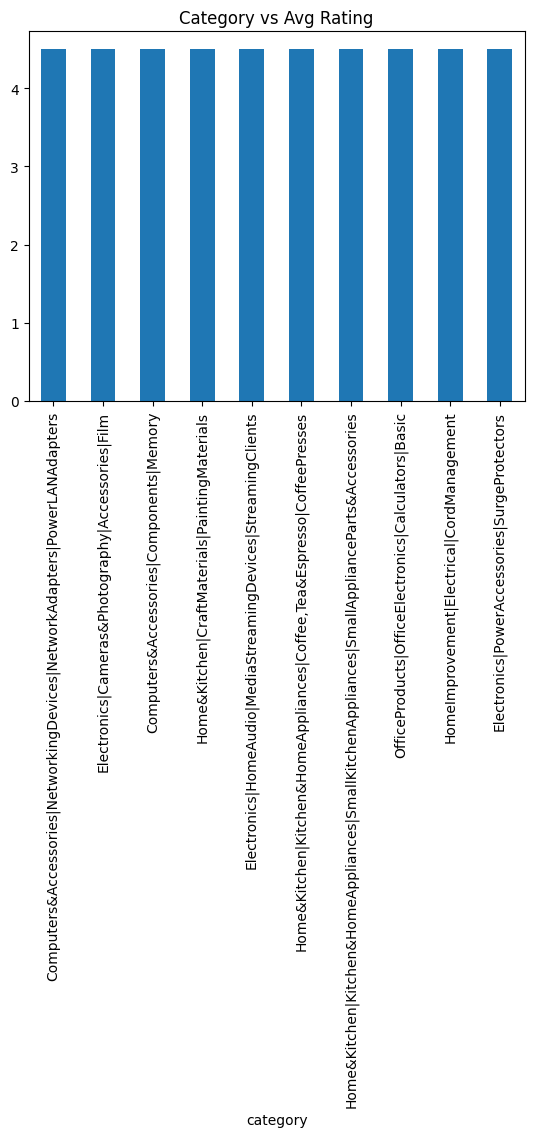

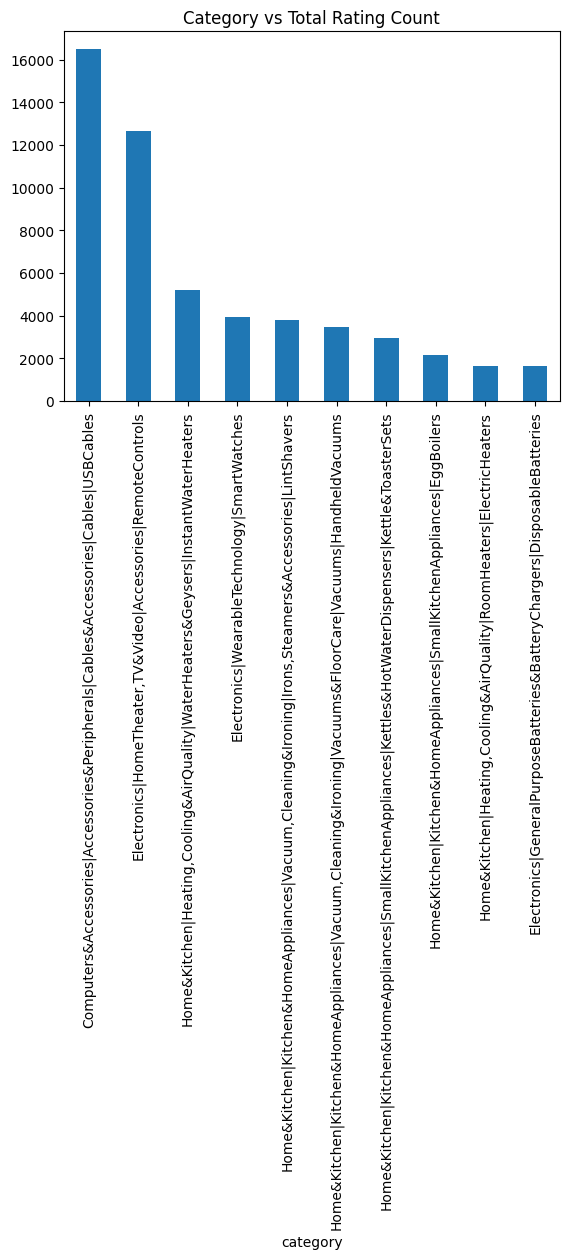

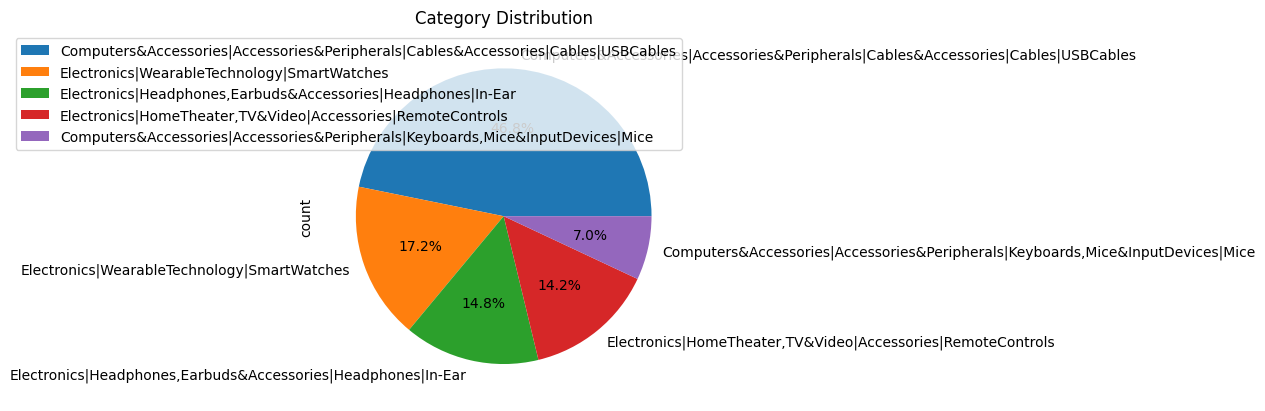

In [ ]:
# 1. Category Performance Dashboard
import matplotlib.pyplot as plt

cat_avg = df.groupby('category')['rating'].mean().sort_values(ascending=False)
cat_count = df.groupby('category')['rating_count'].sum().sort_values(ascending=False)

# Avg Rating
cat_avg.head(10).plot(kind='bar')
plt.title("Category vs Avg Rating")
plt.show()

# Rating Count
cat_count.head(10).plot(kind='bar')
plt.title("Category vs Total Rating Count")
plt.show()

# Pie Chart
df['category'].value_counts().head(5).plot.pie(autopct='%1.1f%%')
plt.title("Category Distribution")
plt.legend()
plt.show()

The category with the highest total rating count is the most dominant, as it attracts the maximum number of customer interactions and reviews.
This indicates high demand, visibility, and engagement in that category compared to others.
Categories with lower rating counts show less customer interest or lower sales volume.
 Example (if Electronics is highest):
# Electronics dominates customer attention because it has the highest number of ratings, indicating strong demand and customer engagement.

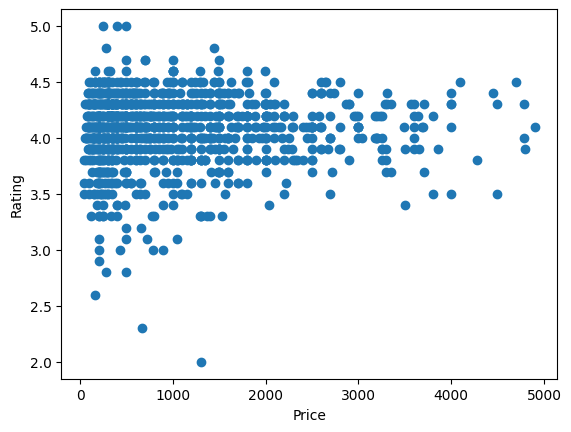

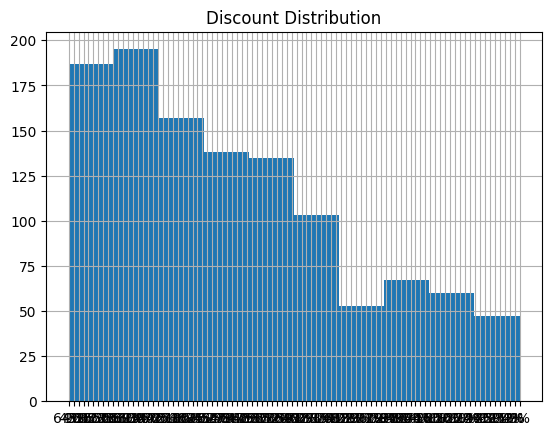

In [ ]:
 # 2. Pricing Strategy Analysis
 # Scatter
plt.scatter(df['discounted_price'], df['rating'])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

# Histogram
df['discount_percentage'].hist()
plt.title("Discount Distribution")
plt.show()

**There is no strong direct relationship between price and rating.
Many mid-priced products often have higher ratings than very expensive ones.**

Expensive products may have:
# Higher expectations → stricter reviews
# Fewer buyers → lower rating_count

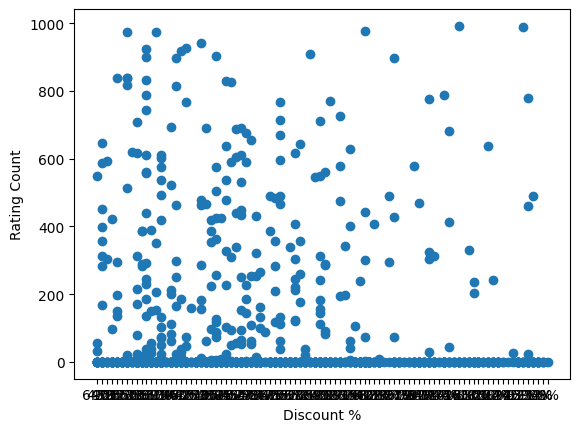

In [ ]:
 # 3. Discount Effectiveness
plt.scatter(df['discount_percentage'], df['rating_count'])
plt.xlabel("Discount %")
plt.ylabel("Rating Count")
plt.show()

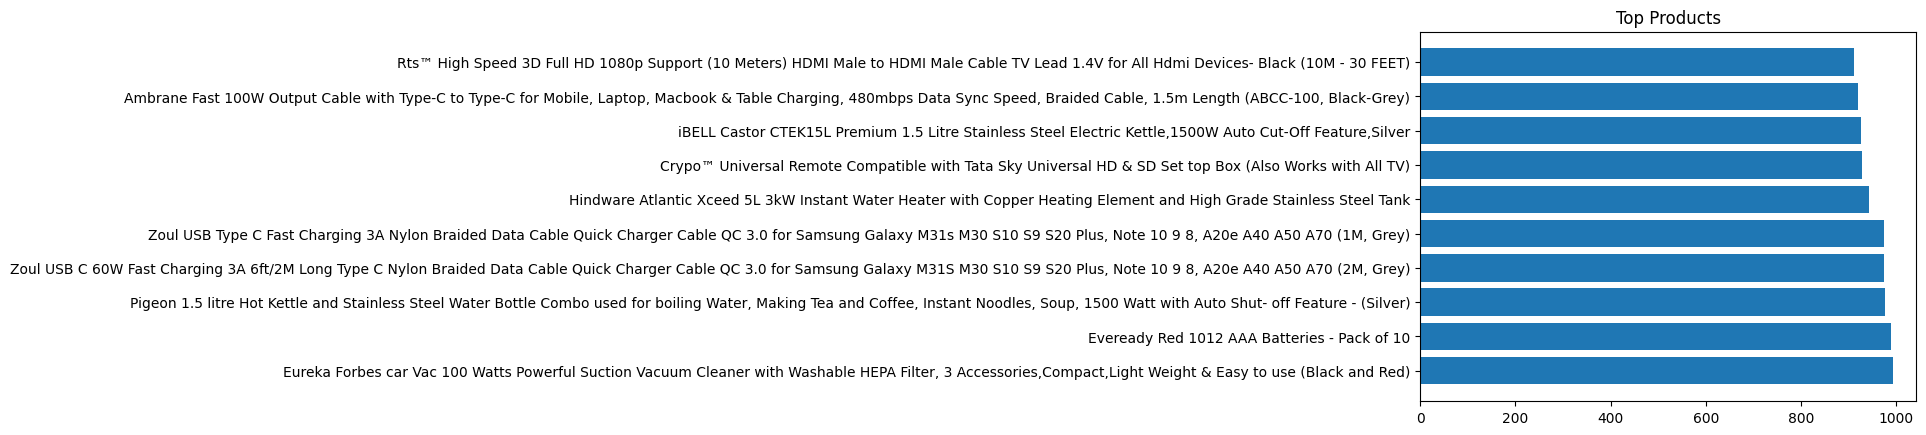

In [ ]:
  # 4. Product Popularity Analysis
top_products = df.sort_values(by='rating_count', ascending=False).head(10)

plt.barh(top_products['product_name'], top_products['rating_count'])
plt.title("Top Products")
plt.show()

**Some products become very popular because they are widely purchased, not because they are perfect.**
    A product can have:
#  High rating + High popularity → Truly strong product
# High popularity + Average rating → Mass-market product
# Low popularity + High rating → Good product but low visibility
# Low popularity + Low rating → Weak product

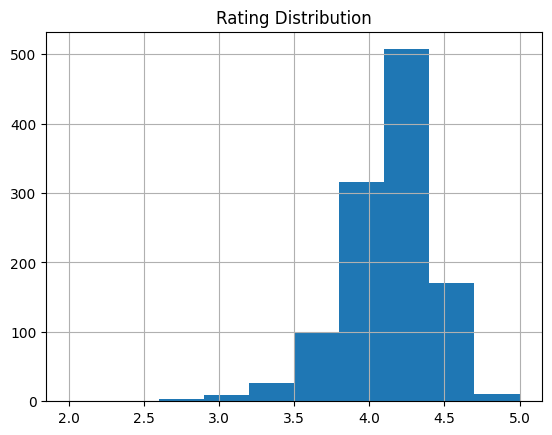

In [ ]:
#  5. Rating Behavior Analysis
df['rating'].hist()
plt.title("Rating Distribution")


plt.show()

**The category with most stable and uniform ratings across products represents consistent quality.
This indicates that the category has reliable product standards and predictable customer satisfaction.
Customers trust such categories more because quality does not vary much between products.**

In [ ]:
top_cat = df['category'].value_counts().head(10).index

df_top = df[df['category'].isin(top_cat)]

<Figure size 1000x600 with 0 Axes>

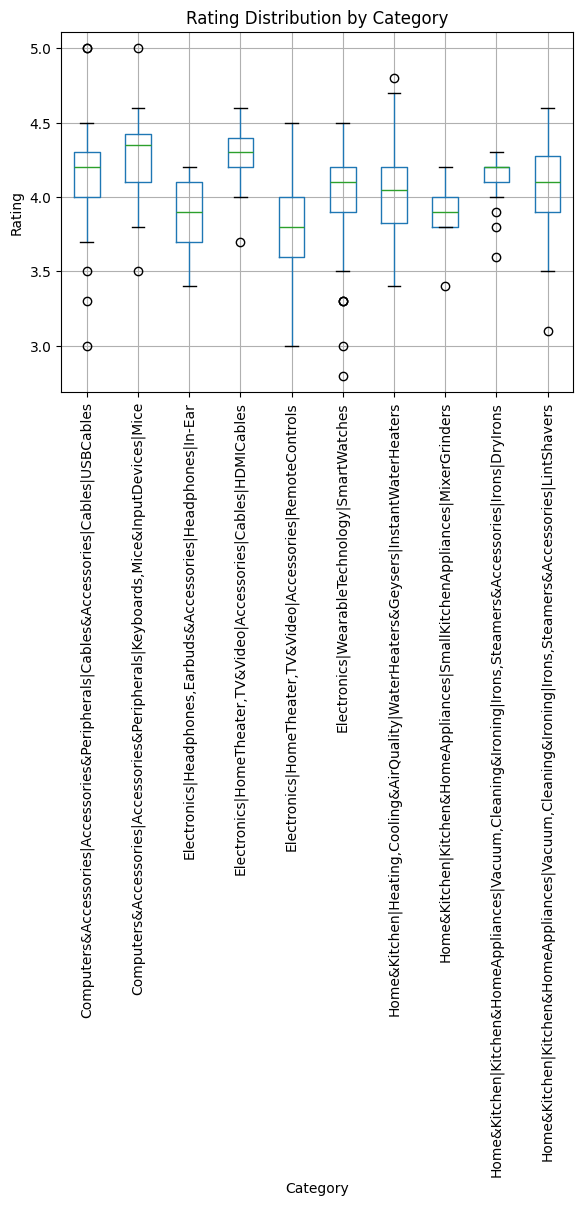

In [ ]:
# boxplot rating disrtubution
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_top.boxplot(column='rating', by='category')

plt.xticks(rotation=90)
plt.title("Rating Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Rating")

plt.show()

In [ ]:
 # 6. Brand / Product Positioning
 # Brand vs Avg Rating
df['brand'] = df['product_name'].astype(str).apply(lambda x: x.split()[0])
print(df)

      product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category  discounted_price  \
0     Computers&Accessories|Accessories&Peripherals|...             39

In [ ]:
df = df[df['brand'].str.len() > 2]

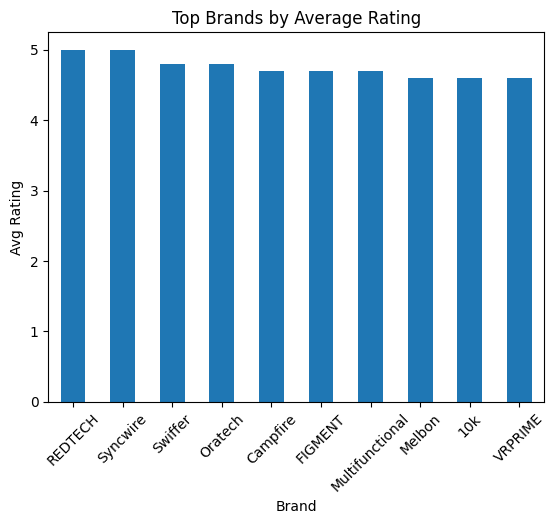

In [ ]:
# brand vs avg rating
brand_rating = df.groupby('brand')['rating'].mean().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt

brand_rating.plot(kind='bar')

plt.title("Top Brands by Average Rating")
plt.xlabel("Brand")
plt.ylabel("Avg Rating")

plt.xticks(rotation=45)
plt.show()

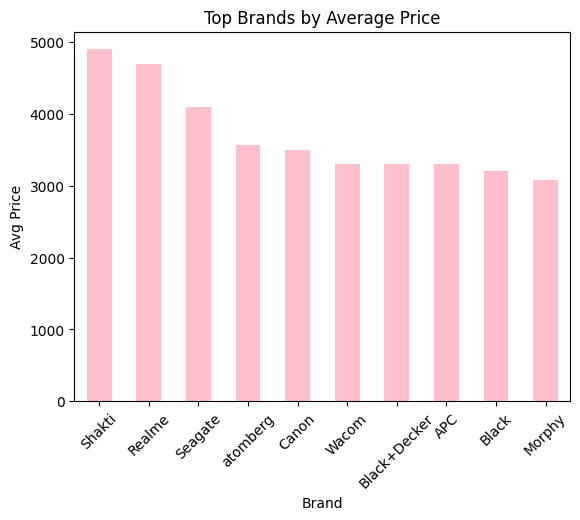

In [ ]:
# brand vs price
brand_price = df.groupby('brand')['discounted_price'].mean().sort_values(ascending=False).head(10)

brand_price.plot(kind='bar', color='pink')

plt.title("Top Brands by Average Price")
plt.xlabel("Brand")
plt.ylabel("Avg Price")

plt.xticks(rotation=45)
plt.show()

SECTION 4: MULTIVARIATE ANALYSIS

In [ ]:
df['popularity_index'] = df['rating'] * df['rating_count']

In [ ]:
df_multi = df[['discounted_price',
               'actual_price',
               'discount_percentage',
               'rating',
               'rating_count',
               'popularity_index']]

In [ ]:
# Remove % and convert to float
df_multi['discount_percentage'] = df_multi['discount_percentage'].str.replace('%','').astype(float)

/tmp/ipykernel_2430/2728157538.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_multi['discount_percentage'] = df_multi['discount_percentage'].str.replace('%','').astype(float)


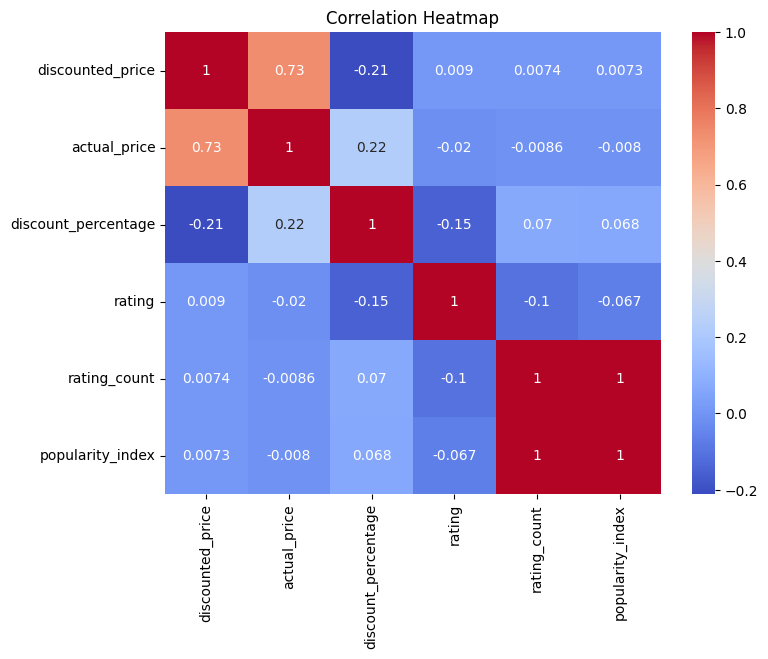

In [ ]:
# Heatmap (correlation)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = df_multi.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

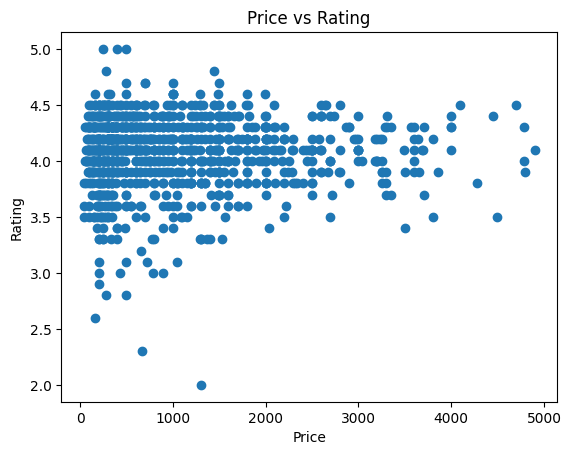

In [ ]:
plt.scatter(df['discounted_price'], df['rating'])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

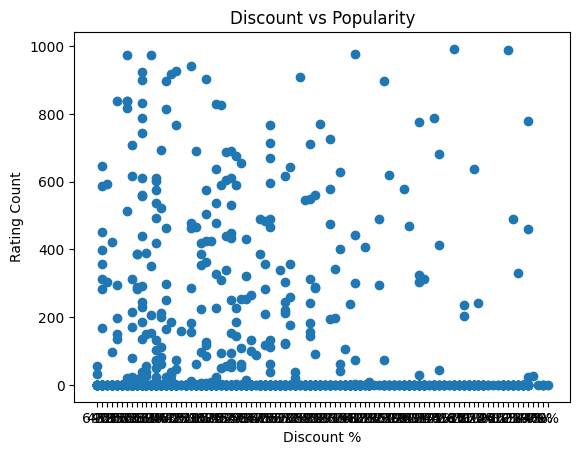

In [ ]:
plt.scatter(df['discount_percentage'], df['rating_count'])
plt.xlabel("Discount %")
plt.ylabel("Rating Count")
plt.title("Discount vs Popularity")
plt.show()

/tmp/ipykernel_2430/3135488719.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


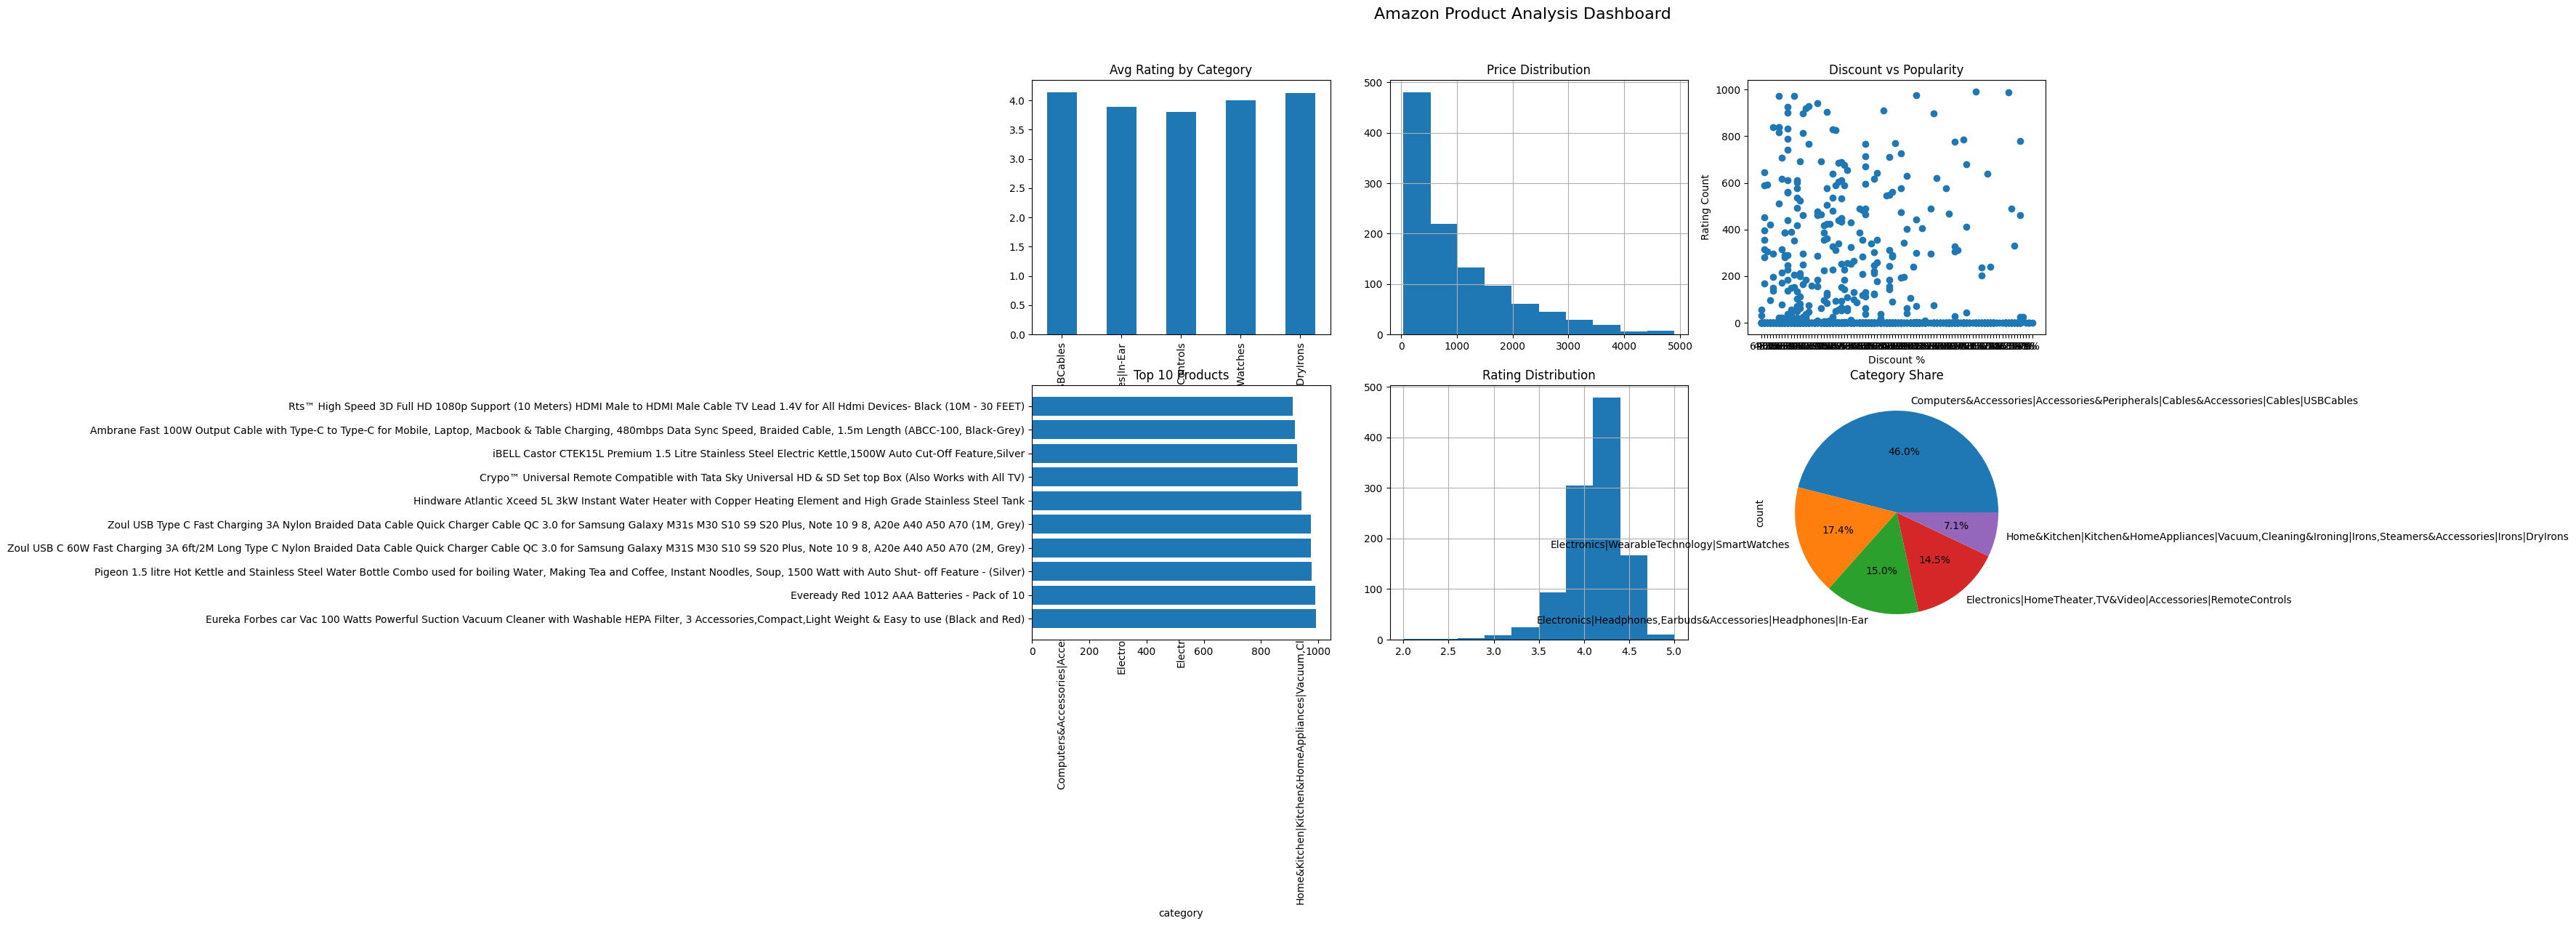

In [ ]:
import matplotlib.pyplot as plt

# Create popularity index
df['popularity_index'] = df['rating'] * df['rating_count']

# Top categories
top_cat = df['category'].value_counts().head(5).index
df_top = df[df['category'].isin(top_cat)]

# Top products
top_products = df.sort_values(by='rating_count', ascending=False).head(10)

# Create figure
plt.figure(figsize=(18,10))

# 1. Category Avg Rating
plt.subplot(2,3,1)
df_top.groupby('category')['rating'].mean().plot(kind='bar')
plt.title("Avg Rating by Category")

# 2. Price Distribution
plt.subplot(2,3,2)
df['discounted_price'].hist()
plt.title("Price Distribution")


# 3. Discount vs Popularity
plt.subplot(2,3,3)
plt.scatter(df['discount_percentage'], df['rating_count'])
plt.xlabel("Discount %")
plt.ylabel("Rating Count")
plt.title("Discount vs Popularity")

# 4. Top Products
plt.subplot(2,3,4)
plt.barh(top_products['product_name'], top_products['rating_count'])
plt.title("Top 10 Products")


# 5. Rating Distribution
plt.subplot(2,3,5)
df['rating'].hist()
plt.title("Rating Distribution")

# 6. Category Share
plt.subplot(2,3,6)
df['category'].value_counts().head(5).plot.pie(autopct='%1.1f%%')
plt.title("Category Share")


plt.suptitle("Amazon Product Analysis Dashboard", fontsize=16)

plt.tight_layout()
plt.show()

**The category with the highest average rating indicates the best overall product quality and customer satisfaction.
It means customers consistently rate products in that category positively, showing strong trust and satisfaction.
This category is the top performer in terms of quality, not just sales or popularity.**

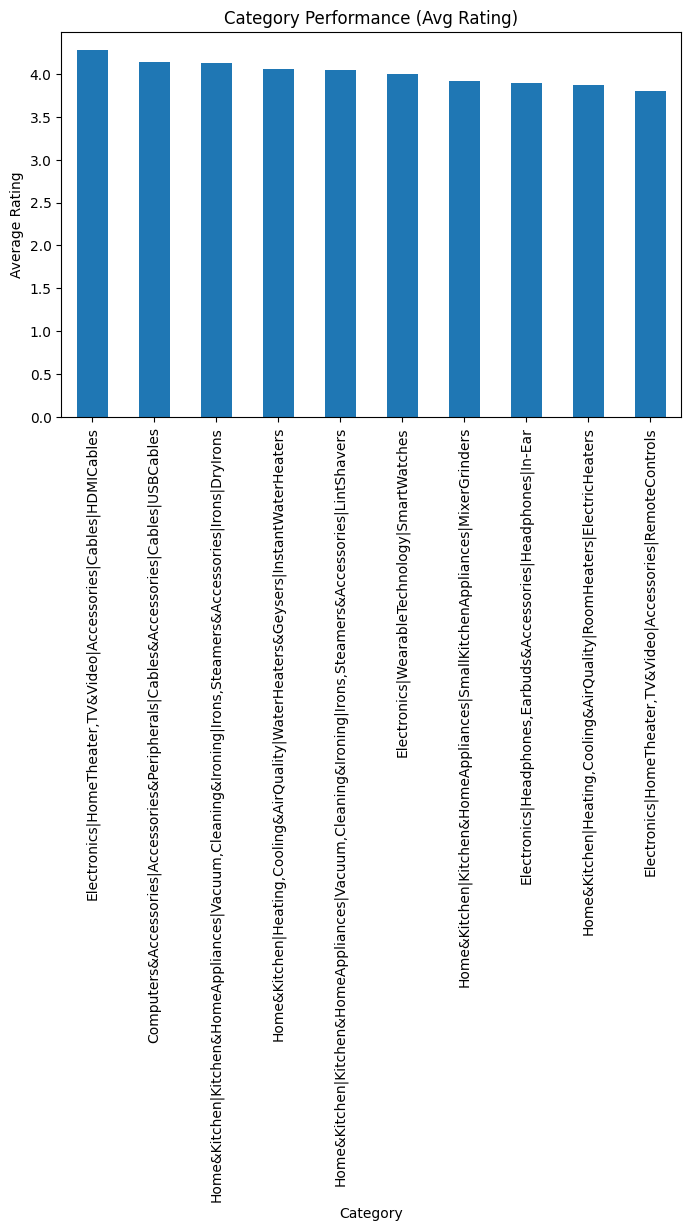

In [ ]:
     # Dashboard Layout (Suggested)
 # 1. Category Performance
 # Category vs Average Rating (Bar Chart)
import matplotlib.pyplot as plt


top_cat = df['category'].value_counts().head(10).index
df_top = df[df['category'].isin(top_cat)]

# Group by category → avg rating
cat_avg = df_top.groupby('category')['rating'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))

cat_avg.plot(kind='bar')

plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.title("Category Performance (Avg Rating)")

plt.xticks(rotation=90)
plt.show()


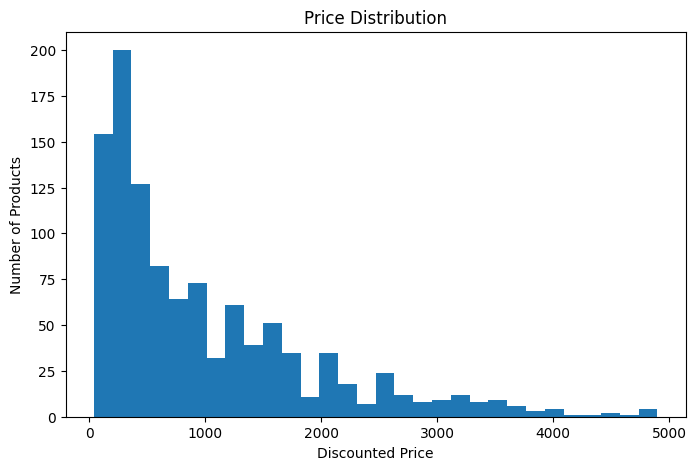

In [ ]:
# 2 price distrubution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['discounted_price'], bins=30)

plt.xlabel("Discounted Price")
plt.ylabel("Number of Products")
plt.title("Price Distribution")

plt.show()

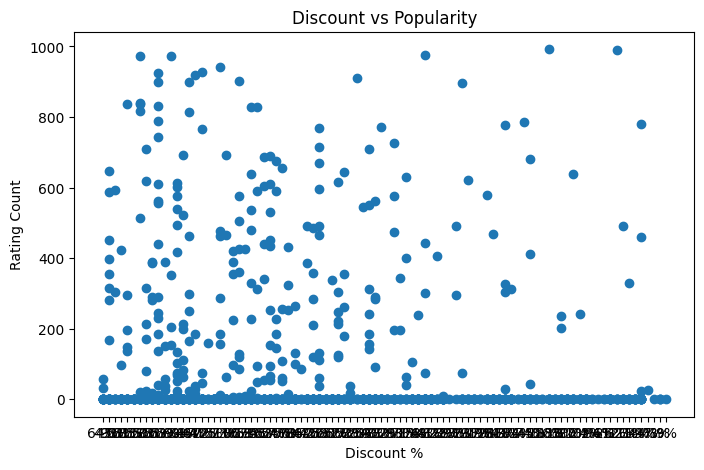

In [ ]:
 #3. Discount vs Popularity (Top Right)
   # Scatter Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df['discount_percentage'], df['rating_count'])

plt.xlabel("Discount %")
plt.ylabel("Rating Count")
plt.title("Discount vs Popularity")

plt.show()

**In most cases, moderate discounts (around 20%–40%) show higher rating counts, meaning better customer engagement.
This suggests that discounts do attract attention and increase product visibility, but only up to an optimal level.
Extremely high discounts do not always guarantee higher engagement—they may sometimes be linked to low-quality or clearance products.**

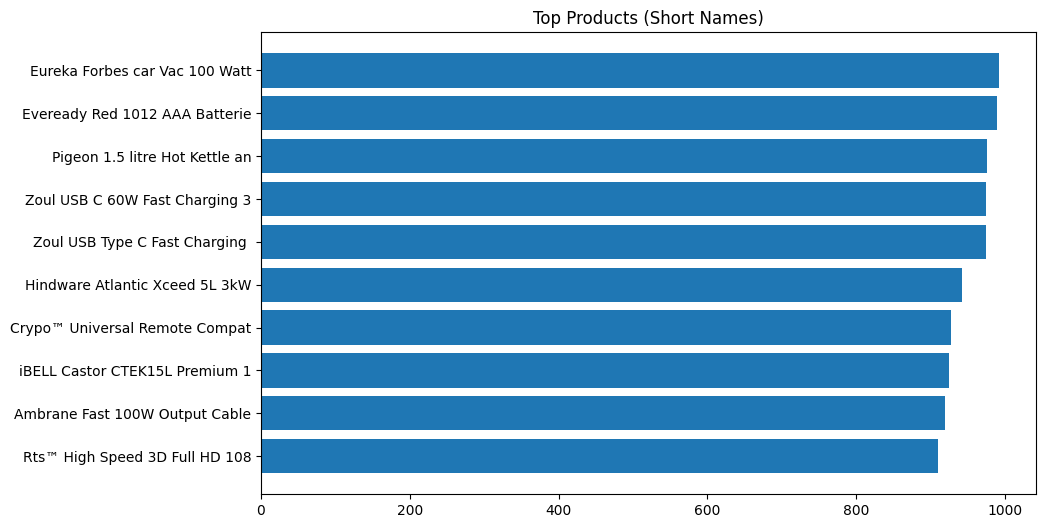

In [ ]:
 # 4. Top Products (Bottom Left)
   # Horizontal Bar Chart
top_products['short_name'] = top_products['product_name'].str[:30]

plt.figure(figsize=(10,6))

plt.barh(top_products['short_name'], top_products['rating_count'])

plt.gca().invert_yaxis()
plt.title("Top Products (Short Names)")
plt.show()

**The top products with highest rating counts are the most popular and widely used items in the dataset.
These products attract maximum customer attention, indicating:
High demand
Strong market visibility
Frequent purchases or usage
Popularity is driven more by exposure, pricing, and usefulness, rather than only rating quality.**

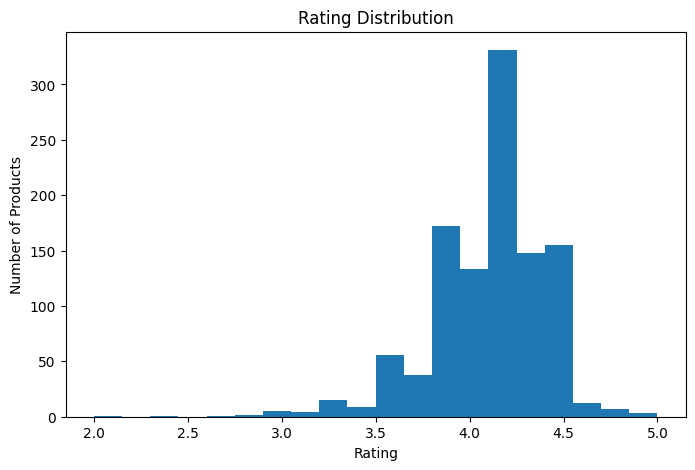

In [ ]:
# 5. Rating Distribution (Bottom Center)
  #  Histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['rating'], bins=20)

plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.title("Rating Distribution")

plt.show()

**If most ratings are concentrated between 4.0 to 4.5, it indicates generally good product quality across the platform.
A right-skewed distribution (more high ratings) suggests that customers are mostly satisfied.
Very few low ratings (1–2 stars) indicate fewer major quality issues or complaints.**

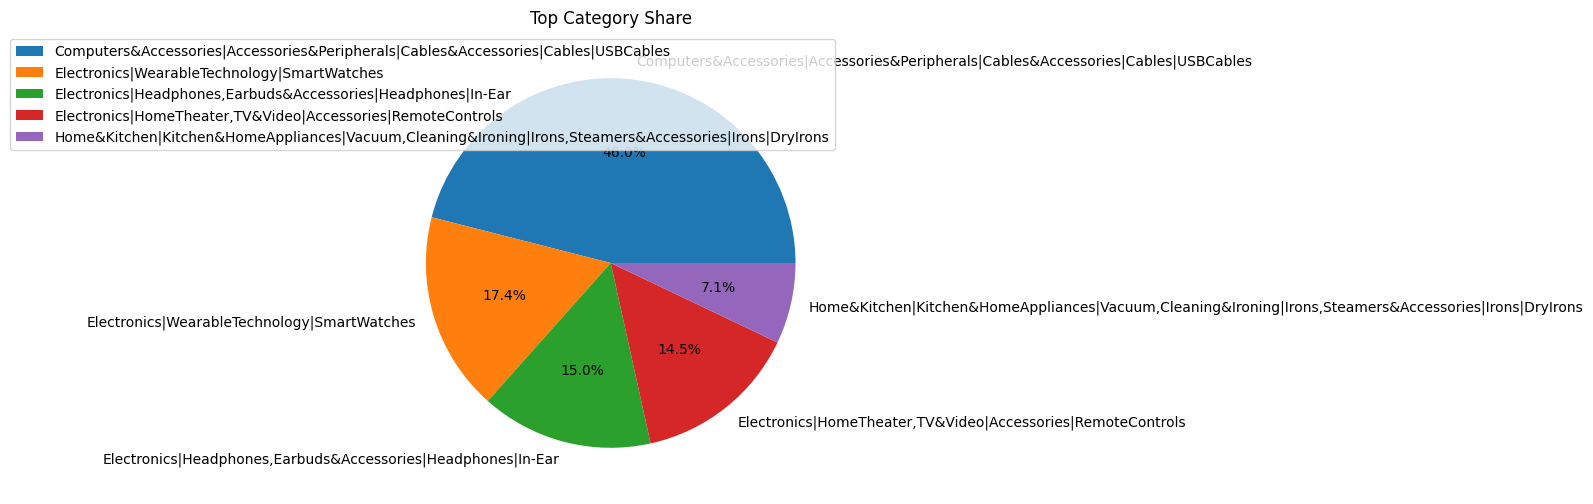

In [ ]:
# 6. Category Share (Bottom Right)
   # Pie Chart
top_cat = df['category'].value_counts().head(5)

plt.figure(figsize=(6,6))

top_cat.plot.pie(autopct='%1.1f%%')

plt.title("Top Category Share")
plt.ylabel("")
plt.legend()

plt.show()

**The category with the largest pie slice represents the highest market share in the dataset.
This means that category has:
More products listed or
Higher customer engagement (depending on metric used)
It indicates which category dominates the platform ecosystem.**

 **SECTION 5: BUSINESS INSIGHTS **

**Best Performing Category

The category with the highest average rating is the best performing, indicating strong product quality and high customer satisfaction.
 This category can be prioritized for premium positioning and expansion.**

Worst Performing Category

 The category with the lowest average rating reflects customer dissatisfaction or inconsistent quality.
 This segment needs quality improvement, better product selection, or review monitoring.

Overpriced but Low-Performing Products

 Some products are priced high but have low ratings and engagement.
 This indicates poor perceived value, where customers do not find the product worth the price.
Such products require price correction or quality enhancement.

Overpriced but Low-Performing Products

 Some products are priced high but have low ratings and engagement.
 This indicates poor perceived value, where customers do not find the product worth the price.
 Such products require price correction or quality enhancement.

High Rating but Low Rating Count

 Some products have excellent ratings but very few reviews.
 This indicates hidden gems that lack visibility.
 These products should be marketed more to boost awareness and sales.

High Discount but Low Popularity

 Heavy discounts do not always result in high engagement.
 This shows that discount alone is not enough — product quality and trust matter more.
 Strategy should focus on balanced pricing + quality, not just discounts.



Low Price but Poor Ratings

 Some low-priced products still receive poor ratings.
 This indicates quality issues even at budget level.
 Such products may harm brand reputation and should be improved or removed.

# FINAL CONCLUSION

**"The analysis shows that pricing and discounts alone do not determine product success. Customer satisfaction is influenced more by product quality, brand trust, and perceived value. While some products achieve high popularity, many remain underutilized despite strong ratings, indicating opportunities for better visibility and marketing."**